# Financial Stress Prediction from Mobile Money Activity

## A leakage-aware classification and calibration study

This notebook presents our final workflow for predicting whether a customer will experience liquidity stress during the next 30 days. The predictors describe six months of mobile money activity, including inflows, withdrawals, balances, merchant payments, bill payments, and account engagement.

The report is written as a reproducible project narrative rather than as a record of every experiment. We focus on the decisions that changed the model, compare them against a consistent validation anchor, and keep local validation separate from public leaderboard evidence.

**Last locally selected candidate:** `submission_v82_dual_residual_rank_best.csv`  
**v82 public score:** 0.735285834  
**v82 revealed private score:** 0.730074958  
**Best public score within this report's scope:** 0.738486037 (`v72`)

The report deliberately stops at v82. Every modelling and parameter-selection decision through v82 was made from training data and out-of-fold evidence. Later submissions that adjusted calibration or ranking using observed public leaderboard scores are outside the scope of this notebook.

## 1. Project goal and evaluation

The aim is to estimate a probability of financial stress for each customer. This is not only a ranking problem: the probabilities should also represent risk accurately. The competition therefore combines two metrics:

- **Log loss (60%)**, which penalises poorly calibrated and overconfident probabilities.
- **ROC-AUC (40%)**, which measures whether stressed customers are ranked above non-stressed customers.

This creates a useful tension. A transformation that preserves rank can improve log loss without changing ROC-AUC, while a new model can improve ranking but damage calibration. We therefore evaluate both quantities throughout the project and never convert probabilities into hard class labels for submission.

Competition reference: [Zindi liquidity stress challenge](https://zindi.world/competitions/liquidity-stress-early-warning-challenge)

## 2. Reproducibility and available data

The raw `Train.csv`, `Test.csv`, and sample submission are available under `winner_public_reference/my_solution_v3/data`. They were obtained from the [public first-place solution repository](https://github.com/Mouhamadmm466/FinancialStress_Solution_Zindi). Before using them, we verified that their training IDs, test IDs, and target values exactly match the saved project artefacts. This provenance is stated explicitly because the public solution is a reference source, not work produced in this project.

The report uses the saved, model-ready matrices for the main experiment history and the raw files for source-level validation and new feature tests.

The saved dataset contains:

- 40,000 training observations and 30,000 test observations;
- 694 numeric model features;
- a binary target with a 15% positive rate;
- five stratified folds created with `SEED = 42`;
- out-of-fold target encodings for training rows;
- scaling fitted on training data only;
- raw monthly transaction columns for 40,000 training and 30,000 test customers.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
ROOT = Path.cwd()

if not (ROOT / "tabular_nn_dataset").exists():
    raise FileNotFoundError("Run this notebook from the Financial Stress Prediction folder.")

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
plt.style.use("seaborn-v0_8-whitegrid")

/Users/taicauston/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/7d/3_zq81ld3dj343hnxxs70fy00000gq/T/matplotlib-j6dzzn4c because there was an issue with the default path (/Users/taicauston/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


In [2]:
DATA_DIR = ROOT / "tabular_nn_dataset"
RAW_DATA_DIR = ROOT / "winner_public_reference" / "my_solution_v3" / "data"

with np.load(DATA_DIR / "X_train_mlp_scaled.npz") as archive:
    X_train = archive["X"]
with np.load(DATA_DIR / "X_test_mlp_scaled.npz") as archive:
    X_test = archive["X"]

y = pd.read_csv(DATA_DIR / "y_train.csv")["target"]
folds = pd.read_csv(DATA_DIR / "folds.csv")["fold"]
train_ids = pd.read_csv(DATA_DIR / "train_ids.csv")["ID"]
test_ids = pd.read_csv(DATA_DIR / "test_ids.csv")["ID"]
feature_names = pd.read_csv(DATA_DIR / "feature_names.csv")["feature"]
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")
summary = json.loads((DATA_DIR / "dataset_summary.json").read_text())
raw_train = pd.read_csv(RAW_DATA_DIR / "Train.csv")
raw_test = pd.read_csv(RAW_DATA_DIR / "Test.csv")

summary

{'train_shape': [40000, 694],
 'test_shape': [30000, 694],
 'target_positive_rate': 0.15,
 'n_features': 694,
 'n_folds': 5,
 'seed': 42,
 'target_encoding': 'OOF for train, full-train mapping for test',
 'scaling': 'StandardScaler fit on train only',
 'files': ['X_train_mlp_scaled.npz',
  'X_test_mlp_scaled.npz',
  'y_train.csv',
  'train_ids.csv',
  'test_ids.csv',
  'feature_names.csv',
  'folds.csv',
  'sample_submission.csv']}

## 3. Data validation

Before modelling, we check that the raw files, matrices, labels, identifiers, folds, and submission template agree. The raw-to-saved ID and target checks prevent a superficially compatible public dataset from being mixed into the experiment history.

In [3]:
validation = pd.DataFrame(
    {
        "check": [
            "training rows",
            "test rows",
            "feature count",
            "training values finite",
            "test values finite",
            "duplicate training IDs",
            "duplicate test IDs",
            "target positive rate",
            "number of folds",
            "submission row count",
            "raw training rows",
            "raw test rows",
            "raw training IDs match saved IDs",
            "raw test IDs match saved IDs",
            "raw target matches saved target",
            "duplicate raw training IDs",
            "duplicate raw test IDs",
        ],
        "value": [
            X_train.shape[0],
            X_test.shape[0],
            X_train.shape[1],
            bool(np.isfinite(X_train).all()),
            bool(np.isfinite(X_test).all()),
            int(train_ids.duplicated().sum()),
            int(test_ids.duplicated().sum()),
            float(y.mean()),
            int(folds.nunique()),
            len(sample_submission),
            len(raw_train),
            len(raw_test),
            bool(raw_train["ID"].equals(train_ids)),
            bool(raw_test["ID"].equals(test_ids)),
            bool(raw_train["liquidity_stress_next_30d"].astype(int).equals(y)),
            int(raw_train["ID"].duplicated().sum()),
            int(raw_test["ID"].duplicated().sum()),
        ],
    }
)

assert X_train.shape == (len(y), len(feature_names))
assert X_test.shape == (len(test_ids), len(feature_names))
assert len(sample_submission) == len(test_ids)
assert set(y.unique()) == {0, 1}
assert set(folds.unique()) == set(range(5))
assert raw_train["ID"].equals(train_ids)
assert raw_test["ID"].equals(test_ids)
assert raw_train["liquidity_stress_next_30d"].astype(int).equals(y)

validation

,check,value
0,training rows,40000
1,test rows,30000
2,feature count,694
3,training values finite,True
4,test values finite,True
5,duplicate training IDs,0
6,duplicate test IDs,0
7,target positive rate,0.150000
8,number of folds,5
9,submission row count,30000


,observations,positive_rate
fold,,
0,8000,0.150000
1,8000,0.150000
2,8000,0.150000
3,8000,0.150000
4,8000,0.150000


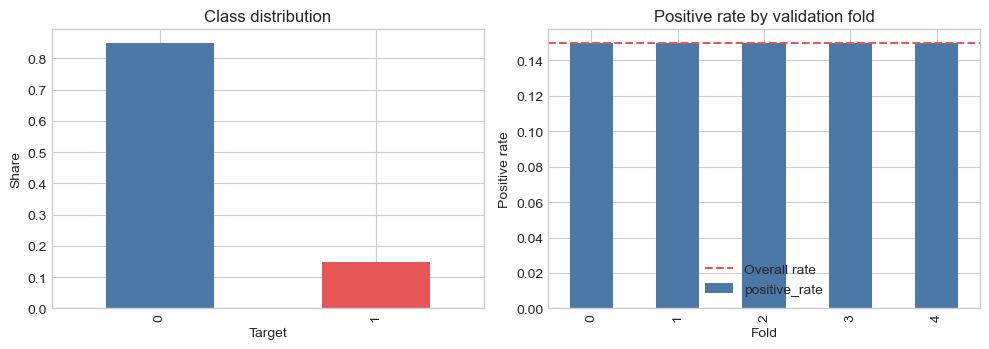

In [4]:
fold_balance = (
    pd.DataFrame({"fold": folds, "target": y})
    .groupby("fold")
    .agg(observations=("target", "size"), positive_rate=("target", "mean"))
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
y.value_counts(normalize=True).sort_index().plot.bar(
    ax=axes[0], color=["#4C78A8", "#E45756"]
)
axes[0].set(title="Class distribution", xlabel="Target", ylabel="Share")
fold_balance["positive_rate"].plot.bar(ax=axes[1], color="#4C78A8")
axes[1].axhline(y.mean(), color="#E45756", linestyle="--", label="Overall rate")
axes[1].set(title="Positive rate by validation fold", xlabel="Fold", ylabel="Positive rate")
axes[1].legend()
plt.tight_layout()

fold_balance

The target is imbalanced but not extremely rare: 15% of training observations are positive. The equal class rate across folds confirms that the saved split is stratified. Accuracy is therefore reported only as a secondary diagnostic; log loss and ROC-AUC are the main criteria.

## 4. Cleaning and preprocessing

The modelling pipeline follows four rules:

1. Numeric missing values and extreme ratios are handled before model fitting.
2. Highly skewed monetary variables are represented with capped or signed `log1p` transformations where appropriate.
3. Target encodings for training observations are generated out of fold. The test mapping is learned from the complete training sample only after validation.
4. Standardisation is fitted on the training matrix and then applied to the test matrix.

These rules keep test information out of training transformations. They also reduce the influence of a small number of unusually large transaction values.

## 5. Feature engineering

The strongest signal came from changes in behaviour, not from isolated monthly totals. We organised the predictors into the following groups:

- **Monthly activity:** month-specific inflow, withdrawal, merchant payment, bill payment, balance, and engagement measures.
- **Recent-versus-older comparisons:** ratios and differences comparing recent months with the earlier part of the six-month window.
- **Liquidity pressure:** net flow relative to outflow, balance drawdown, and withdrawal stress.
- **Stable transformations:** capped ratios and signed logarithms for variables with long tails.
- **Customer context:** segment, region, earning pattern, and group-relative standardised values.
- **Categorical interactions and target encodings:** smoothed risk information for a restricted set of economically meaningful groups.

All engineered variables describe information available at the observation date. No feature uses the future 30-day target window.

In [5]:
name_series = feature_names.astype(str)
feature_groups = {
    "monthly variables": name_series.str.match(r"^m[1-6]_"),
    "ratios and shares": name_series.str.contains("ratio|share", case=False, regex=True),
    "recent vs older": name_series.str.contains("recent_to_older|minus_older", case=False, regex=True),
    "log or capped": name_series.str.contains("log1p|capped|clip", case=False, regex=True),
    "target encoded": name_series.str.contains("target_enc|_te", case=False, regex=True),
    "group relative": name_series.str.contains("_z_by_|region|segment|earning", case=False, regex=True),
}

group_counts = pd.Series(
    {group: int(mask.sum()) for group, mask in feature_groups.items()},
    name="feature_count",
).sort_values(ascending=False)

group_counts.to_frame()

,feature_count
monthly variables,203
group relative,188
log or capped,91
ratios and shares,58
recent vs older,57
target encoded,14


## 6. Validation design

We use five-fold stratified cross-validation with a fixed seed. Out-of-fold predictions are stored for every model so that calibration and stacking can be assessed on observations that were not used to fit the corresponding base model.

The final workflow applies three evidence gates:

1. A candidate must improve both the overall out-of-fold result and the majority of folds.
2. Calibration must be fitted inside the validation procedure or on genuinely out-of-fold predictions.
3. Public leaderboard results are recorded separately. A local improvement is not treated as confirmed until the uploaded file improves the public score.

This last distinction became important: several complex rerankers improved a local proxy but reduced the public score.

## 7. Model development

We began with gradient-boosted trees because the data are tabular, nonlinear, and contain many interactions between transaction channels. CatBoost was the strongest individual family. XGBoost and LightGBM added some diversity, but broad ensembles did not consistently transfer to the leaderboard.

The main progression was:

1. CatBoost models with recent-stress ratios and target-encoded groups.
2. Seed averaging and mild downweighting of likely label-noise observations.
3. A diagnostic stack of complementary out-of-fold predictions.
4. Clean rank-preserving calibration to balance ROC-AUC and log loss.

Neural and specialised alternatives were retained only when they contributed independent signal. The table below shows why GRU, TabM, pairwise ranking, local-neighbour, and cross-flow variants were not included in the final model.

In [6]:
v34_models = pd.read_csv(ROOT / "v34_strategy_oof_scores.csv")
v34_stack = pd.read_csv(ROOT / "v34_stack_scores.csv")

local_comparison = pd.DataFrame(
    [
        {
            "candidate": "Best v34 CatBoost base",
            "evaluation": "5-fold OOF",
            "roc_auc": v34_models.iloc[0]["roc_auc"],
            "log_loss": v34_models.iloc[0]["log_loss"],
            "decision": "retain as diverse base",
        },
        {
            "candidate": "v34 diagnostic stack",
            "evaluation": "5-fold OOF",
            "roc_auc": v34_stack.iloc[0]["roc_auc"],
            "log_loss": v34_stack.iloc[0]["log_loss"],
            "decision": "use for diagnostics",
        },
        {
            "candidate": "Corrected native-category CatBoost",
            "evaluation": "fold 0 pilot",
            "roc_auc": pd.read_csv(ROOT / "v54_corrected_catboost_pilot_scores.csv").iloc[0]["corrected_auc"],
            "log_loss": pd.read_csv(ROOT / "v54_corrected_catboost_pilot_scores.csv").iloc[0]["corrected_log_loss"],
            "decision": "discard",
        },
        {
            "candidate": "Temporal GRU",
            "evaluation": "fold 0 pilot",
            "roc_auc": pd.read_csv(ROOT / "v55_temporal_gru_pilot_scores.csv").iloc[0]["temporal_auc"],
            "log_loss": pd.read_csv(ROOT / "v55_temporal_gru_pilot_scores.csv").iloc[0]["temporal_log_loss"],
            "decision": "discard",
        },
        {
            "candidate": "Nested target encoding",
            "evaluation": "fold 0 pilot",
            "roc_auc": pd.read_csv(ROOT / "v56_nested_te_pilot_scores.csv").iloc[0]["nested_te_auc"],
            "log_loss": pd.read_csv(ROOT / "v56_nested_te_pilot_scores.csv").iloc[0]["nested_te_log_loss"],
            "decision": "discard",
        },
        {
            "candidate": "Pairwise XGBoost ranker",
            "evaluation": "fold 0 pilot",
            "roc_auc": pd.read_csv(ROOT / "v59_xgb_pairwise_pilot_scores.csv").iloc[0]["ranker_auc"],
            "log_loss": np.nan,
            "decision": "discard",
        },
        {
            "candidate": "Cross-flow CatBoost",
            "evaluation": "fold 0 pilot",
            "roc_auc": pd.read_csv(ROOT / "v66_crossflow_catboost_pilot_scores.csv").iloc[0]["new_model_auc"],
            "log_loss": pd.read_csv(ROOT / "v66_crossflow_catboost_pilot_scores.csv").iloc[0]["new_model_log_loss"],
            "decision": "discard",
        },
        {
            "candidate": "TabM ensemble",
            "evaluation": "fold 0 pilot",
            "roc_auc": pd.read_csv(ROOT / "v68_tabm_pilot_scores.csv").iloc[0]["tabm_auc"],
            "log_loss": pd.read_csv(ROOT / "v68_tabm_pilot_scores.csv").iloc[0]["tabm_log_loss"],
            "decision": "discard",
        },
        {
            "candidate": "PCA plus nearest neighbours",
            "evaluation": "5-fold OOF",
            "roc_auc": pd.read_csv(ROOT / "v70_similarity_fold_scores.csv")["knn_auc"].mean(),
            "log_loss": pd.read_csv(ROOT / "v70_similarity_fold_scores.csv")["knn_log_loss"].mean(),
            "decision": "discard",
        },
    ]
)

local_comparison

,candidate,evaluation,roc_auc,log_loss,decision
0,Best v34 CatBoost base,5-fold OOF,0.920160,0.246040,retain as diverse base
1,v34 diagnostic stack,5-fold OOF,0.922112,0.227845,use for diagnostics
2,Corrected native-category CatBoost,fold 0 pilot,0.909706,0.249270,discard
3,Temporal GRU,fold 0 pilot,0.881452,0.277273,discard
4,Nested target encoding,fold 0 pilot,0.911024,0.247404,discard
5,Pairwise XGBoost ranker,fold 0 pilot,0.845199,NaN,discard
6,Cross-flow CatBoost,fold 0 pilot,0.920557,0.234661,discard
7,TabM ensemble,fold 0 pilot,0.890365,0.268250,discard
8,PCA plus nearest neighbours,5-fold OOF,0.769464,0.373167,discard


The full-OOF and fold-0 values are not directly comparable, so the pilot rows are used only as rejection tests. Each rejected model was sufficiently below the fold-0 reference that completing a five-fold run would have added cost without changing the decision.

In [7]:
v77 = pd.read_csv(ROOT / "v77_simple_rank_ensemble_scores.csv")
v77_view = v77[
    [
        "model_count",
        "roc_auc",
        "auc_gain_vs_reference",
        "folds_improved",
        "minimum_fold_gain",
        "models",
    ]
].head(8)

v77_view

,model_count,roc_auc,auc_gain_vs_reference,folds_improved,minimum_fold_gain,models
0,2,0.920243,0.000082,3,-0.000153,oof_cat_noise_mild_less_combos_seedavg_raw | o...
1,2,0.920411,0.000251,3,-0.000211,oof_cat_noise_mild_less_combos_seedavg_raw | o...
2,3,0.920399,0.000238,3,-0.000242,oof_cat_noise_mild_less_combos_seedavg_raw | o...
3,3,0.920416,0.000256,3,-0.000285,oof_cat_noise_mild_less_combos_seedavg_raw | o...
4,2,0.920435,0.000274,3,-0.000308,oof_cat_noise_mild_less_combos_seedavg_raw | o...
5,4,0.920360,0.000199,3,-0.000454,oof_cat_noise_mild_less_combos_seedavg_raw | o...
6,3,0.920296,0.000136,3,-0.000561,oof_cat_noise_mild_less_combos_seedavg_raw | o...
7,3,0.920322,0.000162,2,-0.000269,oof_cat_noise_mild_less_combos_seedavg_raw | o...


The v77 test used equal-weight rank averages of eight diverse raw CatBoost, XGBoost, and LightGBM predictions. Its best combination gained only 0.00008 AUC overall, improved three of five folds, and lost 0.00015 AUC in its weakest fold. It therefore failed the pre-specified stability gate and no submission file was created.

### Public-solution feature audit

The public first-place solution motivated a new feature audit rather than a direct reuse of its submitted predictions. It summarises recent changes in income, spending, balance, activity, transaction diversity, and cash-flow pressure. We reconstructed our recorded v34 CatBoost pipeline exactly on fold 0, then added 129 non-overlapping temporal signals from that public feature design.

The reconstruction reproduced the archived v34 result exactly, which is an important reproducibility check. The complete new block improved fold-0 AUC by only 0.000054 and log loss by 0.000350. Six smaller economic feature families were then tested separately; none improved AUC.

A full five-fold run confirmed that the augmented model should not replace v34: AUC improved in only two folds and the mean composite gain was approximately zero. However, the model's errors contained a small amount of useful contrary information. A conservative residual rank adjustment against the augmented model and a locally retrained HistGradientBoosting model improved the reference AUC by 0.000093, with positive gains in all five folds. Candidate v82 preserves the exact probability distribution of v57 and changes only customer ordering. Its leaderboard performance remains unverified.

In [8]:
v78 = pd.read_csv(ROOT / "v78_winner_features_v34_fold0.csv")
v79 = pd.read_csv(ROOT / "v79_winner_feature_groups_fold0.csv")

public_feature_audit = pd.concat(
    [
        v78[
            [
                "model",
                "feature_count",
                "roc_auc",
                "log_loss",
                "auc_gain_vs_reconstruction",
                "log_loss_gain_vs_reconstruction",
            ]
        ].rename(
            columns={
                "auc_gain_vs_reconstruction": "auc_gain_vs_v34",
                "log_loss_gain_vs_reconstruction": "log_loss_gain_vs_v34",
            }
        ),
        v79[
            [
                "model",
                "feature_count",
                "roc_auc",
                "log_loss",
                "auc_gain_vs_v34",
                "log_loss_gain_vs_v34",
            ]
        ],
    ],
    ignore_index=True,
)

public_feature_audit.sort_values("auc_gain_vs_v34", ascending=False)

,model,feature_count,roc_auc,log_loss,auc_gain_vs_v34,log_loss_gain_vs_v34
1,v34_plus_winner_signals,1029,0.927469,0.234546,0.000054,0.000350
0,v34_reconstruction,900,0.927415,0.234896,0.000000,0.000000
2,persistence_volatility,939,0.927331,0.234836,-0.000083,0.000060
3,direction_extremes,939,0.927292,0.234991,-0.000123,-0.000096
4,compact_economic,914,0.927273,0.235354,-0.000142,-0.000458
5,entropy_core,908,0.927224,0.235137,-0.000191,-0.000241
6,compact_plus_entropy,922,0.927223,0.235182,-0.000192,-0.000286
7,range_position,926,0.927039,0.235438,-0.000376,-0.000542


In [9]:
v81_folds = pd.read_csv(ROOT / "v81_winner_signals_full_cv_fold_scores.csv")
v82 = pd.read_csv(ROOT / "v82_dual_residual_rank_summary.csv")

display(v81_folds)
v82

,fold,roc_auc,log_loss,competition_score,baseline_roc_auc,baseline_log_loss,baseline_competition_score,auc_gain,log_loss_gain,competition_score_gain
0,1,0.927469,0.234546,0.830260,0.927415,0.234896,0.830029,0.000054,0.000350,0.000231
1,2,0.922141,0.243533,0.822737,0.922069,0.243786,0.822556,0.000072,0.000253,0.000181
2,3,0.917004,0.251841,0.815697,0.917187,0.251278,0.816108,-0.000183,-0.000563,-0.000411
3,4,0.916003,0.251974,0.815217,0.916132,0.251654,0.815460,-0.000128,-0.000320,-0.000243
4,5,0.916827,0.251270,0.815969,0.916958,0.251815,0.815694,-0.000130,0.000546,0.000275


,file,reference_oof_auc,candidate_oof_auc,auc_gain,folds_improved,minimum_fold_gain,hist_residual_weight,augmented_residual_weight,retrained_hist_max_abs_diff_vs_saved,corr_with_v57,mean_abs_diff_vs_v57,mean_pred,std_pred,min_pred,max_pred
0,submission_v82_dual_residual_rank_best.csv,0.922432,0.922525,0.000093,5,0.000008,0.010000,0.110000,0.153918,0.997244,0.010143,0.154226,0.245070,0.000005,0.999966


## 8. Calibration and rank preservation

ROC-AUC depends only on ordering, whereas log loss depends on the probability scale. We therefore tested monotonic transformations using out-of-fold predictions. The v57 procedure applies beta-style calibration to prediction ranks and blends the calibrated result with the preceding model.

Later local experiments tested broader rank-transfer models, mean adjustments, and alternative rank calibration. A candidate was retained only when its parameters were selected without using its public score. v72 is the strongest public result within this local-only sequence, while v82 is the final model developed before public-score-guided calibration began.

v82 preserves the calibrated probability distribution and changes only ordering. Its two residual signals were trained from out-of-fold errors using the winner-inspired temporal feature audit. The selected residual weights improved ROC-AUC in all five folds.

In [10]:
v57 = pd.read_csv(ROOT / "v57_clean_rankcal_summary.csv").iloc[0]
v65 = pd.read_csv(ROOT / "v65_broad_ranktransfer_summary.csv").iloc[0]
v72 = pd.read_csv(ROOT / "v72_rankcal_mean_search_summary.csv").iloc[0]
v82 = pd.read_csv(ROOT / "v82_dual_residual_rank_summary.csv").iloc[0]

calibration_comparison = pd.DataFrame(
    [
        {
            "version": "v57 clean rank calibration",
            "local_roc_auc": v57["clean_cv_auc"],
            "local_log_loss": v57["clean_cv_log_loss"],
            "folds_improved": np.nan,
            "role": "calibrated anchor",
        },
        {
            "version": "v65 broad rank transfer",
            "local_roc_auc": v65["candidate_oof_auc"],
            "local_log_loss": v65["proxy_candidate_log_loss"],
            "folds_improved": np.nan,
            "role": "rejected broader reranker",
        },
        {
            "version": "v72 rank calibration",
            "local_roc_auc": v72["cv_auc"],
            "local_log_loss": v72["cv_log_loss"],
            "folds_improved": np.nan,
            "role": "locally selected calibration",
        },
        {
            "version": "v82 dual residual rank",
            "local_roc_auc": v82["candidate_oof_auc"],
            "local_log_loss": np.nan,
            "folds_improved": int(v82["folds_improved"]),
            "role": "last local-only candidate",
        },
    ]
)

calibration_comparison

,version,local_roc_auc,local_log_loss,folds_improved,role
0,v57 clean rank calibration,0.920141,0.230642,NaN,calibrated anchor
1,v65 broad rank transfer,0.923376,0.226477,NaN,rejected broader reranker
2,v72 rank calibration,0.920141,0.230642,NaN,locally selected calibration
3,v82 dual residual rank,0.922525,NaN,5.000000,last local-only candidate


## 9. Leaderboard evaluation after model selection

Leaderboard values in this section are outcomes, not tuning inputs. They were recorded only after each candidate had been selected from local evidence. v60, v64, and v65 demonstrate that small local reranking gains did not transfer consistently. v72 achieved the best public score in this report's scope.

v82 is the final candidate included. Although it improved OOF ROC-AUC by `0.0000926` and improved all five folds, its public and private scores were worse. This negative result is retained because it shows why a stable local gain can still fail under train-test shift.

In [11]:
leaderboard_results = pd.DataFrame(
    [
        {"version": "v57", "public_score": 0.738435416, "private_score": 0.731769457},
        {"version": "v60", "public_score": 0.738064844, "private_score": 0.732150306},
        {"version": "v64", "public_score": 0.738008153, "private_score": 0.730544444},
        {"version": "v65", "public_score": 0.737738930, "private_score": 0.731033037},
        {"version": "v72", "public_score": 0.738486037, "private_score": 0.731758665},
        {"version": "v82", "public_score": 0.735285834, "private_score": 0.730074958},
    ]
)

leaderboard_results["private_minus_public"] = (
    leaderboard_results["private_score"] - leaderboard_results["public_score"]
)
leaderboard_results

,version,public_score,private_score,private_minus_public
0,v57,0.738435,0.731769,-0.006666
1,v60,0.738065,0.732150,-0.005915
2,v64,0.738008,0.730544,-0.007464
3,v65,0.737739,0.731033,-0.006706
4,v72,0.738486,0.731759,-0.006727
5,v82,0.735286,0.730075,-0.005211


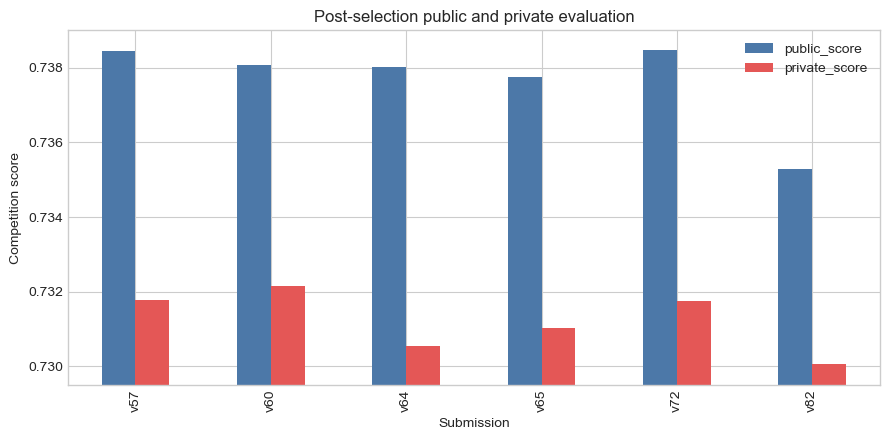

In [12]:
plot_data = leaderboard_results.set_index("version")[["public_score", "private_score"]]
ax = plot_data.plot.bar(figsize=(9, 4.5), color=["#4C78A8", "#E45756"])
ax.set_ylim(0.7295, 0.7390)
ax.set(
    ylabel="Competition score",
    xlabel="Submission",
    title="Post-selection public and private evaluation",
)
ax.legend()
plt.tight_layout()

## 10. Model interpretation

The approximate CatBoost importance table supports the economic interpretation of the model. The most useful variables describe deteriorating cash-flow conditions: a lower recent inflow share, weaker recent net flow relative to outflow, larger balance drawdown, and increasing withdrawal or bill-payment stress.

Importance does not imply a causal effect. Correlated ratios can divide importance across several related features, and target-encoded variables combine information from multiple categories. We therefore interpret families of variables rather than a single ranking position.

,feature,importance
0,recent_inflow_share_6m,7.522989
1,total_inflow_value_recent_to_older_ratio,7.096457
2,recent_net_to_outflow_ratio_capped_v13,6.363886
3,recent_net_to_outflow_ratio,5.054617
4,recent_net_to_outflow_ratio_signed_log1p_v13,4.588637
5,withdraw_value_stress_recent_to_older_ratio,4.502515
6,recent_balance_drawdown_ratio_v13_capped_v13,4.017627
7,balance_stress_recent_to_older_ratio,3.874554
8,withdraw_total_value_recent_to_older_ratio,3.768861
9,recent_balance_drawdown_ratio_v13_z_by_segment,3.742252


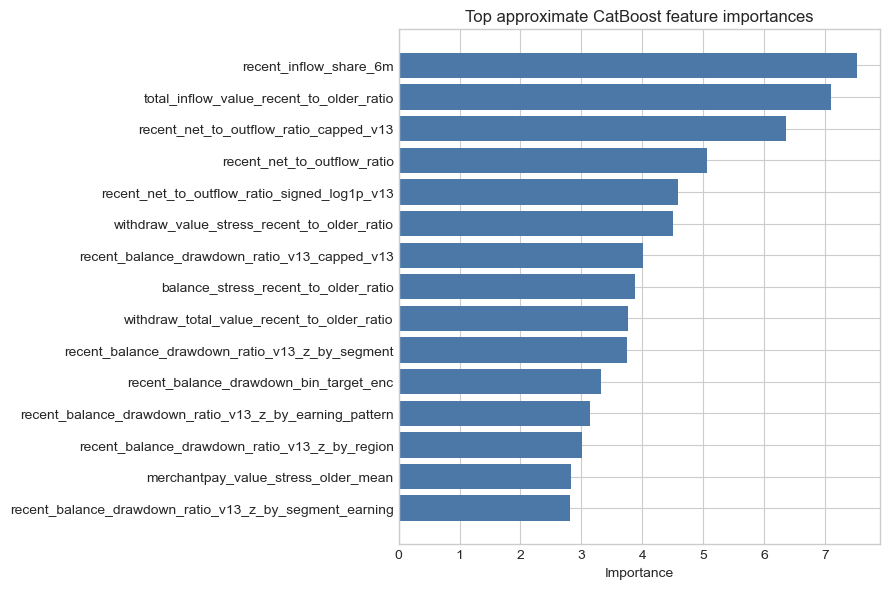

In [13]:
importance = pd.read_csv(ROOT / "v34_approx_catboost_feature_importance.csv")
top_importance = importance.nlargest(15, "importance").sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_importance["feature"], top_importance["importance"], color="#4C78A8")
ax.set(title="Top approximate CatBoost feature importances", xlabel="Importance")
plt.tight_layout()

top_importance.sort_values("importance", ascending=False)

## 11. Final local-only candidate validation

The v82 file must preserve test ID order, contain one probability per row, and avoid missing, infinite, rounded, or out-of-range values. The checks below validate the exact candidate that marks the end of this report.

In [14]:
submission_path = ROOT / "submission_v82_dual_residual_rank_best.csv"
submission = pd.read_csv(submission_path)

submission_checks = pd.Series(
    {
        "rows": len(submission),
        "columns": list(submission.columns),
        "ids_match_template": submission["ID"].equals(sample_submission["ID"]),
        "duplicate_ids": int(submission["ID"].duplicated().sum()),
        "missing_probabilities": int(submission["Target"].isna().sum()),
        "finite_probabilities": bool(np.isfinite(submission["Target"]).all()),
        "within_open_unit_interval": bool(
            submission["Target"].between(0, 1, inclusive="neither").all()
        ),
        "minimum_probability": submission["Target"].min(),
        "mean_probability": submission["Target"].mean(),
        "maximum_probability": submission["Target"].max(),
        "oof_auc_gain": v82["auc_gain"],
        "folds_improved": int(v82["folds_improved"]),
        "observed_public_score": 0.735285834,
        "observed_private_score": 0.730074958,
    }
)

assert submission_checks["ids_match_template"]
assert submission_checks["duplicate_ids"] == 0
assert submission_checks["missing_probabilities"] == 0
assert submission_checks["finite_probabilities"]
assert submission_checks["within_open_unit_interval"]

submission_checks

rows                                30000
columns                      [ID, Target]
ids_match_template                   True
duplicate_ids                           0
missing_probabilities                   0
finite_probabilities                 True
within_open_unit_interval            True
minimum_probability              0.000005
mean_probability                 0.154226
maximum_probability              0.999966
oof_auc_gain                     0.000093
folds_improved                          5
observed_public_score            0.735286
observed_private_score           0.730075
dtype: object

## 12. Limitations

1. The raw competition files are sourced from a public first-place repository rather than a fresh platform download. Their IDs and target match the saved project artefacts exactly, but the provenance should remain visible.
2. Stratified folds estimate average generalisation but may not reproduce all forms of hidden train-test shift.
3. Many candidate predictions are extremely correlated, so small OOF differences can be unstable.
4. The public leaderboard measures only a subset of the test data. Its values are reported after selection and are not used to retune any method in this notebook.
5. The winner-derived feature audit improved only two of five folds as a standalone model. The v82 residual adjustment was more stable locally but failed on both leaderboard splits.
6. Feature importance is model-specific and unstable when predictors are strongly correlated.
7. The data describe association, not causation. A high predicted risk should not be interpreted as evidence that a particular transaction behaviour causes financial stress.

## 13. Conclusion

The project produced a strong calibrated tree-based model and then tested whether new residual ranking signals could add information. v72 obtained the best public score within the local-only workflow at **0.738486037**. The final model-development step was v82, which combined two winner-inspired residual signals and improved OOF ROC-AUC by **0.0000926** across all five folds.

That local gain did not transfer: v82 scored **0.735285834** publicly and **0.730074958** privately. The result does not invalidate the validation design, but it shows that the residual models captured relationships that differed between training and test data.

This notebook stops at that point. Later experiments that inferred calibration or ranking parameters from public leaderboard responses are excluded. A future extension should improve the shift-aware validation design or add genuinely new data rather than tune another small transformation against leaderboard feedback.